# 2D proof of concept

We now model:

$$\frac{\partial ^2 u}{\partial t^2} = c^2\frac{\partial^2u}{\partial x^2}$$

with boudary conditions: $u(x=0,t)=u(x=l,t)=0$


In [34]:
from __future__ import annotations

import os
import sys

# import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random
import equinox as eqx
import jax
import jax.numpy as jnp
from jax.random import PRNGKey
import jax.random as jr
import optax

import matplotlib.pyplot as plt
from matplotlib import rcParams

## Goal

The aim of this notebook is to test whether a Physics-Informed Neural Network (PINN) can recover the solution of the 1D wave equation from **sparse observations**, without ever seeing the full solution on a dense grid.

The workflow is:
1. Compute a reference solution with a classical numerical solver (method of lines + RK45)
2. Sub-sample a small fraction of that solution to simulate realistic measurement conditions
3. Train a PINN that combines a **data loss** (fit the observations) and a **physics loss** (satisfy the PDE) to reconstruct the full solution

## Reference solution: method of lines

The wave equation is a PDE in both space and time. The **method of lines** discretises only the spatial dimension with finite differences, converting the PDE into a large system of coupled ODEs (one per grid point). Time integration is then handled by a standard ODE solver (RK45 here).

This produces a dense, accurate reference on the full $(x, t)$ grid which serves as ground truth.

Solving PDE...


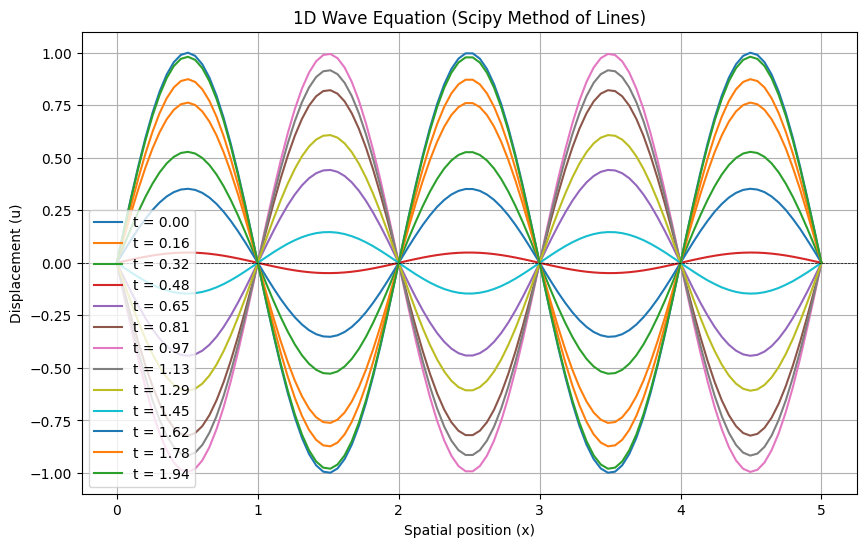

In [35]:
from scipy.integrate import solve_ivp


# ==========================================
# 1. DEFINE PARAMETERS & GRID
# ==========================================
L = 5.0  # Length of the string
c = 1.0  # Wave speed
T_max = 2.0  # Total simulation time
N = 100  # Number of spatial grid points

# Create the spatial grid
x_inter = np.linspace(0, L, N)
dx = L / (N - 1)  # Distance between adjacent grid points


# ==========================================
# 2. DEFINE THE PDE (METHOD OF LINES)
# ==========================================
def wave_equation(t, y, c, dx):
    """
    Computes the time derivatives for the ODE solver.
    The state vector 'y' contains both position (u) and velocity (v).
    y = [u_0, u_1, ..., u_N, v_0, v_1, ..., v_N]
    """
    # Split the state vector back into position (u) and velocity (v)
    u = y[:N]
    v = y[N:]

    # Initialize arrays for our time derivatives
    du_dt = np.zeros_like(u)
    dv_dt = np.zeros_like(v)

    # Equation 1: The derivative of position is velocity
    du_dt[1:-1] = v[1:-1]

    # Equation 2: The derivative of velocity is acceleration (c^2 * d2u/dx2)
    # We use Central Finite Difference to estimate the spatial derivative
    d2u_dx2 = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx**2
    dv_dt[1:-1] = (c**2) * d2u_dx2

    # BOUNDARY CONDITIONS: u(0, t) = 0 and u(L, t) = 0
    # Because du_dt and dv_dt were initialized to zeros, indices 0 and -1
    # remain 0. This mathematically "pins" the ends of the string so they never move.

    # Pack everything back into a single 1D array for scipy
    return np.concatenate([du_dt, dv_dt])


# ==========================================
# 3. SET INITIAL CONDITIONS
# ==========================================
# Let's "pluck" the string in the middle like a guitar
u_initial = np.sin(np.pi * x_inter)  # Initial shape (half a sine wave)
v_initial = np.zeros_like(x_inter)  # Initial velocity is zero (released from rest)

# Combine into the initial state vector
y0 = np.concatenate([u_initial, v_initial])

# ==========================================
# 4. SOLVE WITH SCIPY
# ==========================================
print("Solving PDE...")
# We ask scipy to evaluate the solution at 50 specific time steps so we can animate it
t_inter = np.linspace(0, T_max, 100)

# solve_ivp uses Runge-Kutta 45 (RK45) by default, which works beautifully here
solution = solve_ivp(
    fun=lambda t, y: wave_equation(t, y, c, dx),
    t_span=[0, T_max],
    y0=y0,
    t_eval=t_inter,
    method="RK45",
)

# ==========================================
# 5. VISUALIZE THE RESULTS
# ==========================================
# Extract just the position data (u) from the solution.
# solution.y has shape (2N, num_time_steps). We only want the first N rows.
u_solution = solution.y[:N, :]

plt.figure(figsize=(10, 6))
plt.title("1D Wave Equation (Scipy Method of Lines)")
plt.xlabel("Spatial position (x)")
plt.ylabel("Displacement (u)")

# Plot the wave at a few different time steps
for i in range(0, len(t_inter), 8):
    plt.plot(x_inter, u_solution[:, i], label=f"t = {t_inter[i]:.2f}")

plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.legend()
plt.grid(True)
plt.show()

## PINN approach

Instead of solving the PDE numerically, we parameterise the solution $u_\theta(x, t)$ as a neural network and train it to simultaneously:
- **match the sparse observations** (data loss)
- **satisfy the wave equation** at a set of randomly sampled collocation points (physics loss)

The physical residual is $\mathcal{R} = \partial_{tt} u_\theta - c^2\, \partial_{xx} u_\theta$, which should be zero everywhere in the domain if the network has learned the correct solution.

### Sparse observations

To simulate a realistic scenario we do not give the PINN the full reference grid. At each of the 100 time steps we randomly draw 1–5 spatial points, giving roughly ~300 observations out of 10 000 grid points (~3%), spread unevenly across space and time.

**Note on input normalisation:** the MLP inputs $(x, t)$ are linearly rescaled to $[-1, 1]$ before being passed to the network. Without this, the different magnitudes of $x \in [0, 5]$ and $t \in [0, 2]$ can distort early gradient updates and slow convergence.

In [36]:
LEARNING_RATE = 1e-3

In [37]:
key = jr.PRNGKey(42)

x_obs_list, t_obs_list, u_obs_list = [], [], []

for i_t, t_val in enumerate(t_inter):
    key, subkey = jr.split(key)
    n_pts = int(
        jr.randint(subkey, shape=(), minval=1, maxval=6)
    )  # 1–5 pts per timestep
    key, subkey = jr.split(key)
    x_indices = jr.choice(
        subkey, jnp.arange(len(x_inter)), shape=(n_pts,), replace=False
    )

    x_obs_list.append(np.array(x_inter[x_indices]))
    t_obs_list.append(np.full(n_pts, t_val))
    u_obs_list.append(u_solution[np.array(x_indices), i_t])

x_obs = jnp.concatenate(x_obs_list)  # shape (total_pts,)
t_obs = jnp.concatenate(t_obs_list)  # shape (total_pts,)
u_obs = jnp.concatenate(u_obs_list)  # shape (total_pts,)

print(f"Total observations: {len(u_obs)} / {100 * 100} full grid points")

degraded_data = jnp.stack((x_obs, t_obs, u_obs), axis=1)
degraded_input = jnp.stack((x_obs, t_obs), axis=1)

degraded_data[:, :2]

Total observations: 304 / 10000 full grid points


Array([[1.7171717 , 0.        ],
       [3.6868687 , 0.02020202],
       [3.838384  , 0.04040404],
       [4.4444447 , 0.04040404],
       [1.7171717 , 0.04040404],
       [0.75757575, 0.06060606],
       [0.7070707 , 0.06060606],
       [1.2626263 , 0.08080808],
       [1.8181819 , 0.08080808],
       [2.7272727 , 0.08080808],
       [3.3838384 , 0.08080808],
       [0.75757575, 0.08080808],
       [2.7777777 , 0.1010101 ],
       [1.1616162 , 0.1010101 ],
       [4.5959597 , 0.1010101 ],
       [1.919192  , 0.1010101 ],
       [0.6060606 , 0.12121212],
       [4.949495  , 0.12121212],
       [4.7474747 , 0.12121212],
       [4.949495  , 0.14141414],
       [3.1818182 , 0.14141414],
       [2.6767676 , 0.16161616],
       [0.35353535, 0.16161616],
       [2.929293  , 0.18181819],
       [4.040404  , 0.18181819],
       [4.4949493 , 0.18181819],
       [0.6060606 , 0.18181819],
       [1.1111112 , 0.2020202 ],
       [2.5757575 , 0.2020202 ],
       [0.25252524, 0.2020202 ],
       [2.

### Network architecture

A simple 4-layer MLP with 100 hidden units per layer and SiLU activations. The network takes $(x, t)$ as input and outputs a scalar $u_\theta(x, t)$. The wave speed $c$ is included as a trainable scalar parameter so the network can also learn it from data.

In [38]:
key = jr.PRNGKey(42)
key, init_key = jr.split(key)


class PINN(eqx.Module):
    mlp: eqx.nn.MLP
    t_max: float = T_max
    x_max: float = L

    # Define parameters as JAX arrays so Equinox/Optax knows to train them
    c_guess: jax.Array

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=1,
            width_size=100,
            depth=4,
            activation=jax.nn.silu,
            key=key,
        )

        # Initialize your unknown parameters (initial guesses)
        self.c_guess = jnp.array(1.0)

    # normalize this sh
    def __call__(self, coords):
        x_norm = (coords[0] / self.x_max) * 2.0 - 1.0
        t_norm = (coords[1] / self.t_max) * 2.0 - 1.0
        scaled_coords = jnp.stack([x_norm, t_norm])
        return self.mlp(scaled_coords)


pinn = PINN(init_key)


In [39]:
result_degraded = jax.vmap(pinn)(degraded_input)
# print("output for each point:", result_degraded)

### Pre-training diagnostic

Before training, we verify that the untrained network output is uncorrelated with the true solution. Points should be scattered randomly around — confirming there is no accidental structure baked in at initialisation.

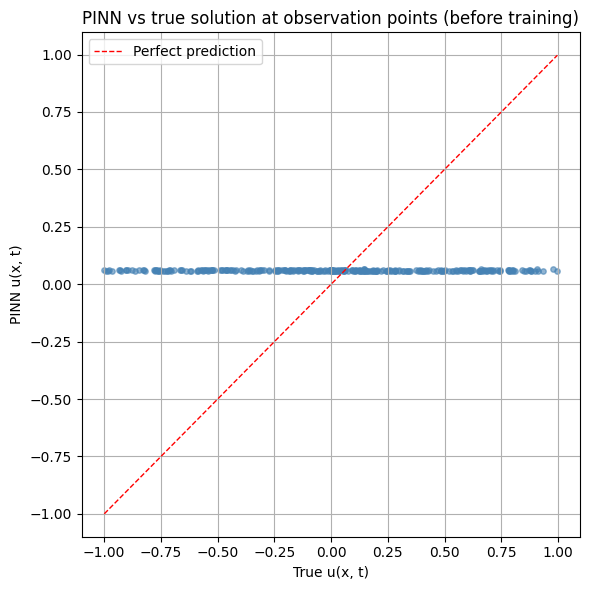

In [40]:
u_pinn_at_obs = jax.vmap(pinn)(degraded_input).squeeze()
u_true_at_obs = degraded_data[:, 2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    np.array(u_true_at_obs), np.array(u_pinn_at_obs), s=15, alpha=0.6, color="steelblue"
)
lim = [float(u_true_at_obs.min()), float(u_true_at_obs.max())]
ax.plot(lim, lim, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("True u(x, t)")
ax.set_ylabel("PINN u(x, t)")
ax.set_title("PINN vs true solution at observation points (before training)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Loss functions

The total loss is a weighted sum of two terms:

$$\mathcal{L} = \lambda_\text{data}\,\mathcal{L}_\text{data} + \lambda_\text{phys}\,\mathcal{L}_\text{phys}$$

- **Data loss** $\mathcal{L}_\text{data}$: MSE between the network output and the sparse observations.
- **Physics loss** $\mathcal{L}_\text{phys}$: MSE of the PDE residual $\partial_{tt}u_\theta - c^2\,\partial_{xx}u_\theta$ at a large set of randomly sampled *collocation points* (10× the number of observations). These points are not tied to any reference solution — the network is simply penalised for violating the PDE there.

The second-order derivatives are computed with forward-over-reverse AD (`jax.jvp` over `jax.grad`). Only the two diagonal entries of the Hessian are needed ($\partial_{xx}$ and $\partial_{tt}$), so this is cheaper than materialising the full Hessian.

In [41]:
# def gradients(network, phase_space_point):
#     """
#     coord: scalar t
#     Returns: all necessary derivatives.
#     """

#     def get_U(c):
#         return network(c)[0]

#     hess = jax.hessian(get_U)(phase_space_point)
#     dU2_dx2 = hess[0, 0]
#     dU2_dt2 = hess[1, 1]

#     return dU2_dx2, dU2_dt2


# Claude suggestion to accelerate the computation of hessian: only compout necessary
def gradients(network, phase_space_point):
    def get_U(c):
        return network(c)[0]

    e_x = jnp.array([1.0, 0.0])
    e_t = jnp.array([0.0, 1.0])

    dU2_dx2 = jax.jvp(jax.grad(get_U), (phase_space_point,), (e_x,))[1][0]
    dU2_dt2 = jax.jvp(jax.grad(get_U), (phase_space_point,), (e_t,))[1][1]

    return dU2_dx2, dU2_dt2


def phys_residuals(network, phase_space_point):
    dU2_dx2, dU2_dt2 = gradients(network, phase_space_point)
    # force parameters to be positive, lol i found a negative mass once
    c = network.c_guess
    res_U = dU2_dt2 - (c**2) * dU2_dx2

    return res_U


def data_loss_fn(network, phase_space_full):

    u_reference = phase_space_full[:, 2]
    x_t_input = phase_space_full[:, :2]
    predictions = jax.vmap(network)(x_t_input)

    return jnp.mean(jnp.square(predictions - u_reference[:, None]))


def loss_fn(
    network,
    phase_space_input,
    LAMBDA_phys,
    LAMBDA_data,
    sampling_key,
):
    """
    Input: network (the NN), inter, inter, the considered time interval,
    """

    N_coloc = 10 * len(phase_space_input)
    x_t_input = phase_space_input[:, :2]
    # u_reference = phase_space_input[:, 2]

    x_input = x_t_input[:, 0]
    t_input = x_t_input[:, 1]

    random_x = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=jnp.min(x_input), maxval=jnp.max(x_input)
    )
    random_t = jr.uniform(
        sampling_key, shape=(N_coloc,), minval=jnp.min(t_input), maxval=jnp.max(t_input)
    )

    random_interval = jnp.stack((random_x, random_t), axis=1)

    phys_residual = jax.vmap(phys_residuals, in_axes=(None, 0))(
        network, random_interval
    )

    phys_loss_contrib = LAMBDA_phys * jnp.mean(jnp.square(phys_residual))

    data_loss_contrib = LAMBDA_data * data_loss_fn(network, phase_space_input)

    total_loss = phys_loss_contrib + data_loss_contrib

    return total_loss, (phys_loss_contrib, data_loss_contrib)


In [42]:
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))


@eqx.filter_jit
def make_step(network, state, phase_space, LAMBDA_phys, LAMBDA_data, sampling_key):

    loss_and_aux, grad = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
        network,
        phase_space,
        LAMBDA_phys,
        LAMBDA_data,
        sampling_key,
    )

    tot_loss, (phys_loss_contrib, data_loss_contrib) = loss_and_aux

    updates, new_state = optimizer.update(grad, state, network)
    new_network = eqx.apply_updates(network, updates)

    return new_network, new_state, tot_loss, phys_loss_contrib, data_loss_contrib


## Training

Adam optimiser for 1000 epochs. The collocation points are resampled at every step so the physics constraint is not over-fit to a fixed set of locations.

In [43]:
# Training loop

LAMBDA_PHYS = 0.5
LAMBDA_DATA = 1.0
EPOCHS = 10000

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

loss_history = []
phys_loss_history = []
data_loss_history = []
key_for_loop = jr.PRNGKey(42)
for epoch in range(EPOCHS):
    key_for_loop, subkey_for_loop = jr.split(key_for_loop)
    pinn, opt_state, loss, phys_loss, data_loss = make_step(
        pinn,
        opt_state,
        degraded_data,
        LAMBDA_PHYS,
        LAMBDA_DATA,
        subkey_for_loop,
    )
    loss_history.append(loss)
    phys_loss_history.append(phys_loss)
    data_loss_history.append(data_loss)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, loss: {loss}")

Epoch: 0, loss: 0.2521270513534546
Epoch: 10, loss: 0.2489214390516281
Epoch: 20, loss: 0.2487584948539734
Epoch: 30, loss: 0.2486303597688675
Epoch: 40, loss: 0.24856849014759064
Epoch: 50, loss: 0.24850249290466309
Epoch: 60, loss: 0.2484244406223297
Epoch: 70, loss: 0.24831876158714294
Epoch: 80, loss: 0.24814917147159576
Epoch: 90, loss: 0.247773215174675
Epoch: 100, loss: 0.24650399386882782
Epoch: 110, loss: 0.2423834353685379
Epoch: 120, loss: 0.2333773821592331
Epoch: 130, loss: 0.22736075520515442
Epoch: 140, loss: 0.2246543914079666
Epoch: 150, loss: 0.22261829674243927
Epoch: 160, loss: 0.22103016078472137
Epoch: 170, loss: 0.21930362284183502
Epoch: 180, loss: 0.21740643680095673
Epoch: 190, loss: 0.2162548303604126
Epoch: 200, loss: 0.21452191472053528
Epoch: 210, loss: 0.21315793693065643
Epoch: 220, loss: 0.21209628880023956
Epoch: 230, loss: 0.21069319546222687
Epoch: 240, loss: 0.2105671912431717
Epoch: 250, loss: 0.20849300920963287
Epoch: 260, loss: 0.207061663269996

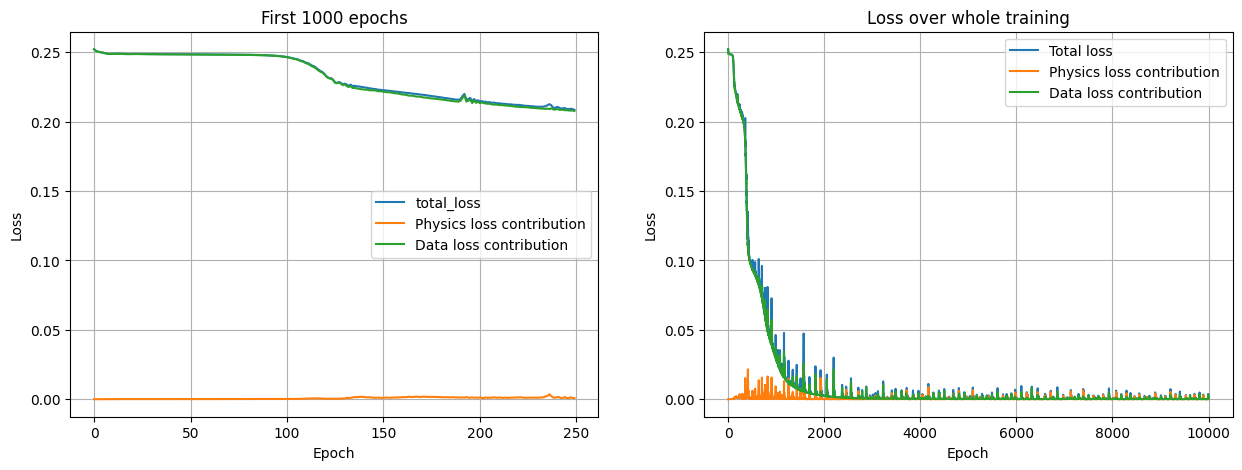

Best loss: 6.91387e-05


In [44]:
epochs = [i for i in range(EPOCHS)]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs[0:250], loss_history[0:250], label="total_loss")
plt.plot(epochs[0:250], phys_loss_history[0:250], label="Physics loss contribution")
plt.plot(epochs[0:250], data_loss_history[0:250], label="Data loss contribution")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("First 1000 epochs")


plt.subplot(1, 2, 2)

plt.plot(epochs, loss_history, label="Total loss")
plt.plot(epochs, phys_loss_history, label="Physics loss contribution")
plt.plot(epochs, data_loss_history, label="Data loss contribution")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over whole training")
plt.legend()
plt.grid()

plt.show()

print("Best loss:", min(loss_history))

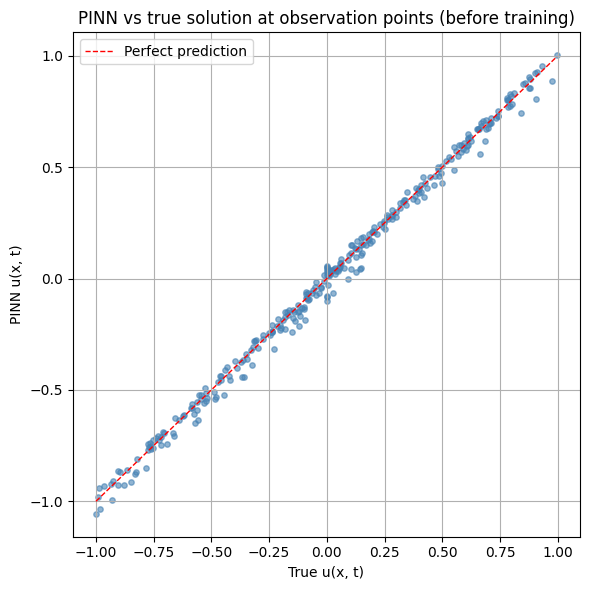

In [45]:
u_pinn_at_obs = jax.vmap(pinn)(degraded_input).squeeze()
u_true_at_obs = degraded_data[:, 2]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    np.array(u_true_at_obs), np.array(u_pinn_at_obs), s=15, alpha=0.6, color="steelblue"
)
lim = [float(u_true_at_obs.min()), float(u_true_at_obs.max())]
ax.plot(lim, lim, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("True u(x, t)")
ax.set_ylabel("PINN u(x, t)")
ax.set_title("PINN vs true solution at observation points (before training)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [46]:
# Extract the learned parameters from the trained network
learned_c = pinn.c_guess.item()


print("=== Learned Physical Parameters ===")

print(f"c:   {learned_c:.4f}")


=== Learned Physical Parameters ===
c:   0.9934


## Results: PINN vs reference solver

Each subplot shows the full spatial profile $u(x, t)$ at a fixed time snapshot. The PINN (red dashed) is evaluated on the same 100-point spatial grid as the reference (black solid). Note that the PINN was **never given the full profile at any of these times** — it saw only 1–5 scattered points per snapshot during training.

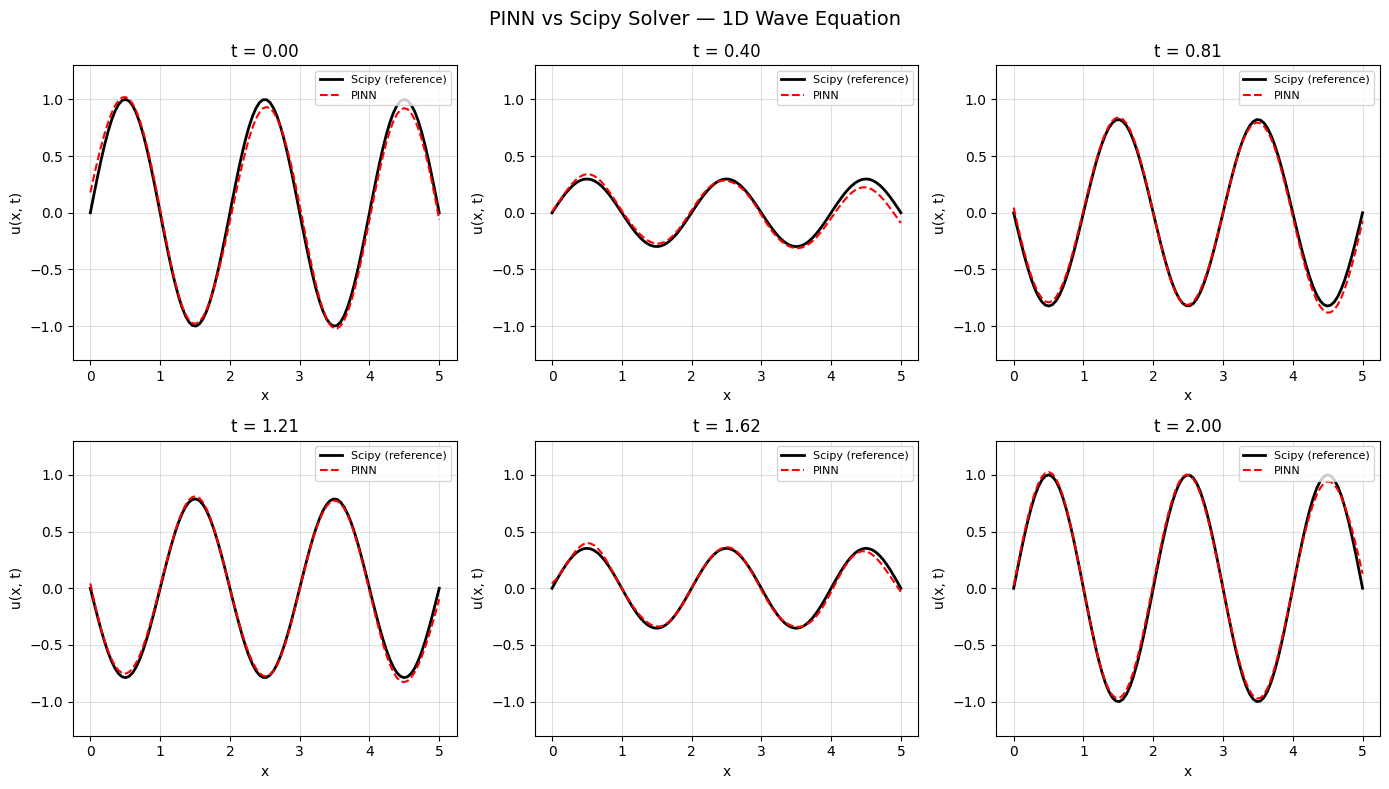

In [47]:
# Comparison: PINN vs Scipy solver at a few selected time steps
t_plot_indices = [0, 20, 40, 60, 80, 99]
x_grid = jnp.array(x_inter)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("PINN vs Scipy Solver — 1D Wave Equation", fontsize=14)

for ax, i_t in zip(axes.flat, t_plot_indices):
    t_val = t_inter[i_t]

    # Scipy reference
    u_ref = u_solution[:, i_t]

    # PINN prediction over the full spatial grid at this t
    coords = jnp.stack([x_grid, jnp.full_like(x_grid, t_val)], axis=1)
    u_pred = jax.vmap(pinn)(coords).squeeze()

    ax.plot(x_inter, u_ref, "k-", linewidth=2, label="Scipy (reference)")
    ax.plot(x_inter, np.array(u_pred), "r--", linewidth=1.5, label="PINN")
    ax.set_title(f"t = {t_val:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x, t)")
    ax.set_ylim(-1.3, 1.3)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()